<a href="https://colab.research.google.com/github/Gayathrini11/Deep-learning/blob/main/DL_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


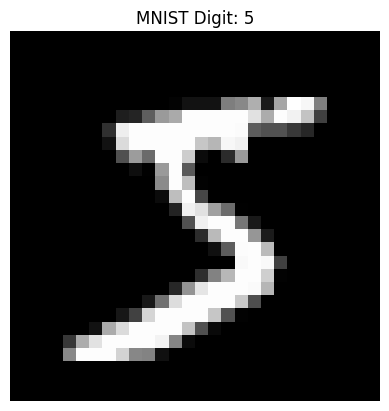

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title("MNIST Digit: " + str(y_train[0]))
plt.axis("off")
plt.show()

In [4]:
image = x_train[0].astype(float) / 255.0

print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [11]:
image = x_train[0].astype(float) / 255.0

In [12]:
vertical_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

horizontal_kernel = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
])

sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

edge_kernel = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

In [13]:
def convolution(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            region = image[i:i+kernel_height, j:j+kernel_width]
            output[i, j] = np.sum(region * kernel)

    return output

In [14]:
vertical_result = convolution(image, vertical_kernel)
horizontal_result = convolution(image, horizontal_kernel)
sharpen_result = convolution(image, sharpen_kernel)
edge_result = convolution(image, edge_kernel)

print("Convolution completed successfully!")
print("Output size:", vertical_result.shape)

Convolution completed successfully!
Output size: (26, 26)


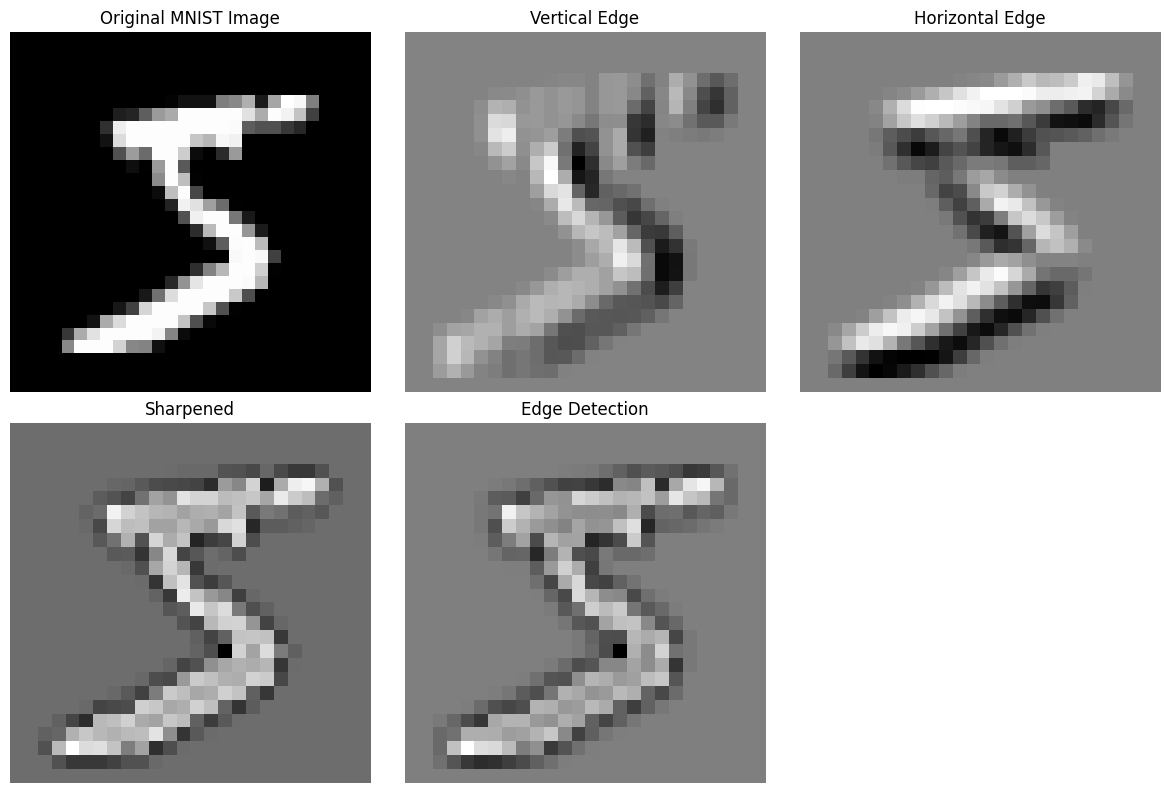

In [15]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original MNIST Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(vertical_result, cmap='gray')
plt.title("Vertical Edge")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(horizontal_result, cmap='gray')
plt.title("Horizontal Edge")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sharpen_result, cmap='gray')
plt.title("Sharpened")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(edge_result, cmap='gray')
plt.title("Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

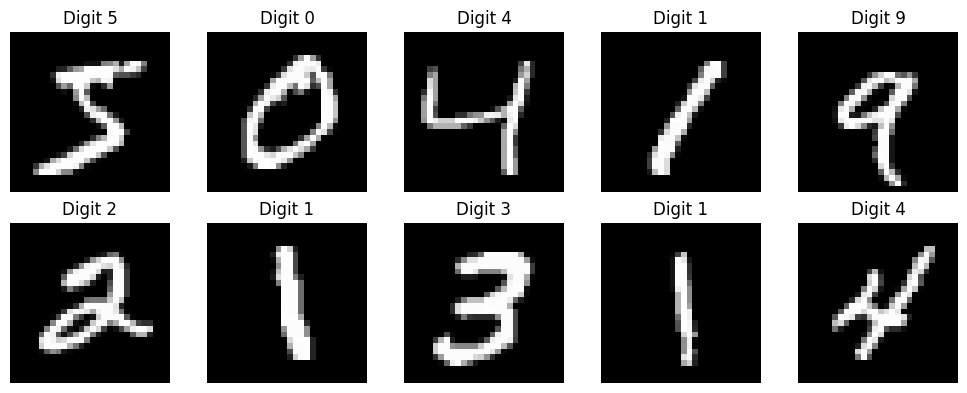

In [16]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Digit " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

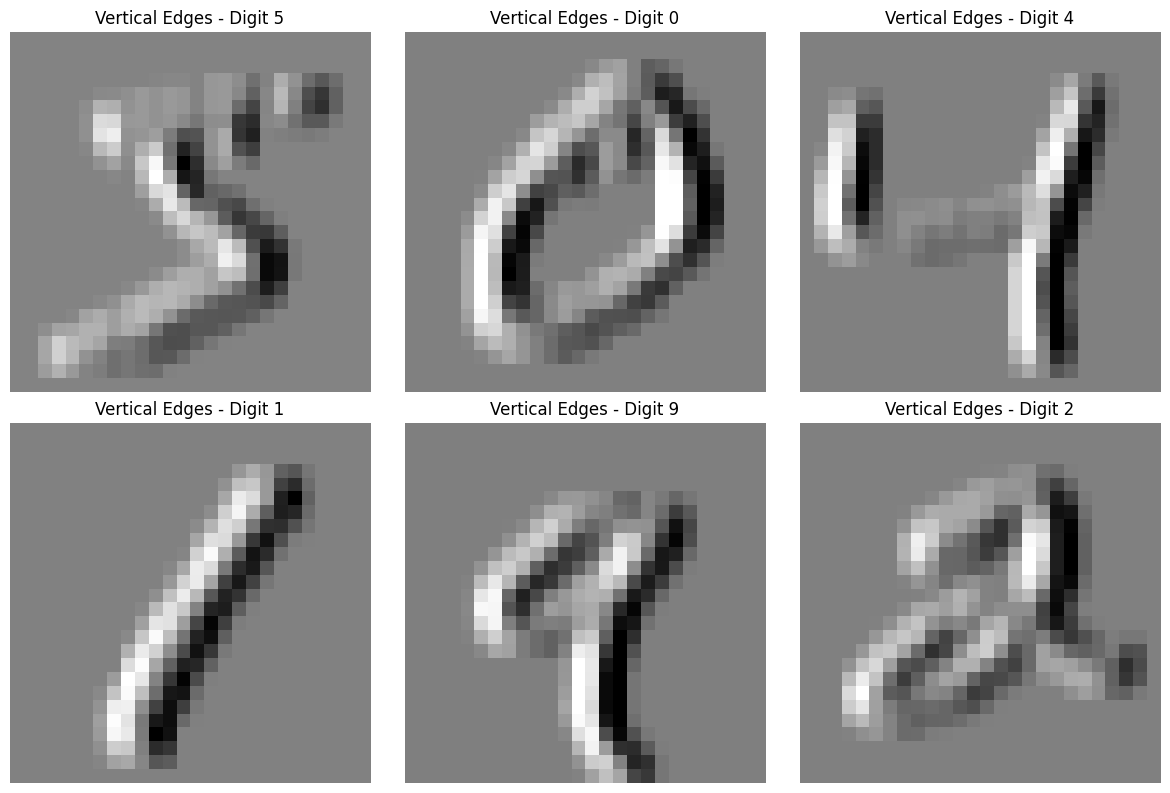

In [17]:
plt.figure(figsize=(12, 8))

for i in range(6):
    image = x_train[i].astype(float) / 255.0
    result = convolution(image, vertical_kernel)

    plt.subplot(2, 3, i + 1)
    plt.imshow(result, cmap='gray')
    plt.title("Vertical Edges - Digit " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

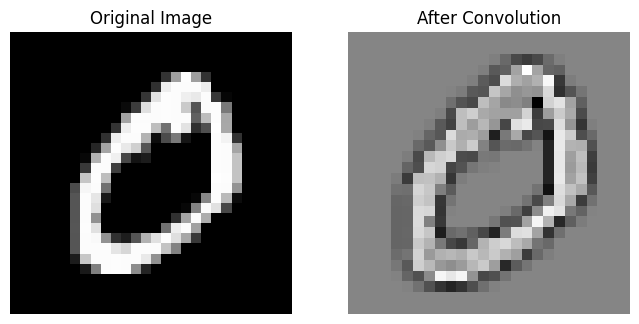

In [18]:
image = x_train[1].astype(float) / 255.0

result = convolution(image, edge_kernel)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title("After Convolution")
plt.axis("off")

plt.show()

In [19]:
image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
image_tensor = tf.reshape(image_tensor, [1, 28, 28, 1])

kernel_tensor = tf.convert_to_tensor(
    edge_kernel, dtype=tf.float32
)

kernel_tensor = tf.reshape(kernel_tensor, [3, 3, 1, 1])

result_tf = tf.nn.conv2d(
    image_tensor,
    kernel_tensor,
    strides=[1, 1, 1, 1],
    padding="VALID"
)

print(result_tf.shape)

(1, 26, 26, 1)
